# Fraud Detection Analysis

This notebook details the technical steps taken to analyze user/device data and identify potential fraud connections, based on the provided `test.xlsx` dataset and instructions.

**Objective:** Identify user accounts associated with known compromised entities (a device and a user account) by analyzing shared attributes like device fingerprints, IP addresses, and other identifiers.

**Compromised Entities:**
- Device ID: `91b12379-8098-457f-a2ad-a94d767797c2` (Bank4)
- User Identity: `0007f265568f1abc1da791e852877df2047b3af9` (Bank8)

In [2]:
# Import necessary libraries
import pandas as pd
import ipinfo
from user_agents import parse
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import Image
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from functions import *
import plotly.graph_objects as go
%matplotlib inline 

## Step 1: Load and Examine Initial Data
First, we load the provided Excel file (`test.xlsx`) and examine its structure, columns, and basic information.

In [2]:
# Load the Excel file
df = pd.read_excel('../data/test.xlsx')

In [3]:
# info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   device_id           1436 non-null   object
 1   identity            1436 non-null   object
 2   bank                1436 non-null   object
 3   device_fingerprint  1436 non-null   object
 4   gpu_renderers       1436 non-null   object
 5   screen              1436 non-null   object
 6   os                  1436 non-null   object
 7   browser             1436 non-null   object
 8   ips                 1436 non-null   object
dtypes: object(9)
memory usage: 101.1+ KB


In [4]:
print(' Data Shape ')
print(df.shape)

 Data Shape 
(1436, 9)


In [5]:
# Display the first 5 rows
df.head()

,device_id,identity,bank,device_fingerprint,gpu_renderers,screen,os,browser,ips
0,00993a56-f44b-448d-9d33-78c16f0be636,37294473,Bank1,b48af28979-116c56e539-9b9e431e93-87a831f69f,Intel(R) Iris(TM) Plus Graphics 655,"(1440, 900, 24)",Mac OS X 10.15.1,Chrome 78.0.3904,185.97.201.89
1,02591b70-e8f5-4299-901c-e78b2b79b526,-,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,"64.52.83.86,154.160.9.113,64.52.83.10"
2,02591b70-e8f5-4299-901c-e78b2b79b526,2577384,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,154.160.10.201
3,02591b70-e8f5-4299-901c-e78b2b79b526,2577384,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,"64.52.83.148,64.52.83.232,154.160.9.113"
4,07e5a1d3-572d-4d5c-b7df-f903c9533fa7,37294473,Bank1,b48af28979-116c56e539-9b9e431e93-87a831f69f,Intel(R) Iris(TM) Plus Graphics 655,"(1440, 900, 24)",Mac OS X 10.15.1,Chrome 78.0.3904,217.66.159.132


In [6]:
df.describe().T

,count,unique,top,freq
device_id,1436,169,614d661d-3a4d-47db-9e2b-874e481260ea,391
identity,1436,333,2577384,223
bank,1436,11,Bank8,400
device_fingerprint,1436,36,C45D75CA94FD92796B0F51000CF754B035AA4E48,391
gpu_renderers,1436,28,-,658
screen,1436,27,"(780, 360, 24)",416
os,1436,24,Android,450
browser,1436,36,Chrome 78.0.3904,290
ips,1436,830,185.97.201.65,50


In [8]:
df.device_id.nunique()

169

In [9]:
df.device_fingerprint.nunique()

36

In [11]:
df.bank.nunique()

11

In [14]:
# check for missing values
print('Missing Values')
print(df.isnull().sum())

Missing Values
device_id             0
identity              0
bank                  0
device_fingerprint    0
gpu_renderers         0
screen                0
os                    0
browser               0
ips                   0
dtype: int64


## Step 2: Data Enrichment

We enrich the initial dataset by extracting detailed information from IP addresses (using the `ipinfo` library) and user agent components (OS and browser strings, using the `user-agents` library).

In [15]:
#convert ips to list
df['ips'] = df['ips'].apply(lambda x: x.split(','))
df['ips'] = df['ips'].apply(lambda x: [i.strip() for i in x])

In [16]:
#conver to list
df['ip'] = df["ips"].copy()


In [17]:
# Split the 'ips_list' column into multiple rows
df = df.explode('ip')

# Reset the index for the new DataFrame
df = df.reset_index(drop=True)

# Display the expanded DataFrame
df.head()

,device_id,identity,bank,device_fingerprint,gpu_renderers,screen,os,browser,ips,ip
0,00993a56-f44b-448d-9d33-78c16f0be636,37294473,Bank1,b48af28979-116c56e539-9b9e431e93-87a831f69f,Intel(R) Iris(TM) Plus Graphics 655,"(1440, 900, 24)",Mac OS X 10.15.1,Chrome 78.0.3904,[185.97.201.89],185.97.201.89
1,02591b70-e8f5-4299-901c-e78b2b79b526,-,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,"[64.52.83.86, 154.160.9.113, 64.52.83.10]",64.52.83.86
2,02591b70-e8f5-4299-901c-e78b2b79b526,-,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,"[64.52.83.86, 154.160.9.113, 64.52.83.10]",154.160.9.113
3,02591b70-e8f5-4299-901c-e78b2b79b526,-,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,"[64.52.83.86, 154.160.9.113, 64.52.83.10]",64.52.83.10
4,02591b70-e8f5-4299-901c-e78b2b79b526,2577384,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,[154.160.10.201],154.160.10.201


### User Agent Enrichment 


In [18]:
import pandas as pd
# --- User Agent Enrichment ---
print("Processing User Agent information...")
ua_details_list = []
for index, row in df.iterrows():
    ua_details_list.append(parse_user_agent(row['browser'], row['os']))

ua_details_df = pd.DataFrame(ua_details_list)
df = pd.concat([df, ua_details_df], axis=1)
print("Added User Agent details to dataframe.")

Processing User Agent information...
Added User Agent details to dataframe.


In [19]:
df.head()

,device_id,identity,bank,device_fingerprint,gpu_renderers,screen,os,browser,ips,ip,ua_browser,ua_browser_version,ua_os,ua_os_version,ua_is_mobile,ua_is_pc
0,00993a56-f44b-448d-9d33-78c16f0be636,37294473,Bank1,b48af28979-116c56e539-9b9e431e93-87a831f69f,Intel(R) Iris(TM) Plus Graphics 655,"(1440, 900, 24)",Mac OS X 10.15.1,Chrome 78.0.3904,[185.97.201.89],185.97.201.89,Chrome,78.0.3904,Mac OS X,10.15.1,False,True
1,02591b70-e8f5-4299-901c-e78b2b79b526,-,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,"[64.52.83.86, 154.160.9.113, 64.52.83.10]",64.52.83.86,Mobile Safari,12.1.2,iOS,12.4.1,True,False
2,02591b70-e8f5-4299-901c-e78b2b79b526,-,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,"[64.52.83.86, 154.160.9.113, 64.52.83.10]",154.160.9.113,Mobile Safari,12.1.2,iOS,12.4.1,True,False
3,02591b70-e8f5-4299-901c-e78b2b79b526,-,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,"[64.52.83.86, 154.160.9.113, 64.52.83.10]",64.52.83.10,Mobile Safari,12.1.2,iOS,12.4.1,True,False
4,02591b70-e8f5-4299-901c-e78b2b79b526,2577384,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,[154.160.10.201],154.160.10.201,Mobile Safari,12.1.2,iOS,12.4.1,True,False


### IP Enrichment 


In [20]:
#initialize ipinfo api
IPINFO_TOKEN="83dc4a94c60d47"
ipinfo_handler = ipinfo.getHandler(IPINFO_TOKEN)

In [21]:
# Avoid redundant lookups using a cache
ip_cache = {}
def enrich_ip(ip):
    if ip not in ip_cache:
        ip_cache[ip] = get_ip_details(ip, ipinfo_handler)
        if not IPINFO_TOKEN:  # throttle only if no token
            time.sleep(0.1)
    return ip_cache[ip]

# Apply enrichment to each row
details_df = df['ip'].apply(enrich_ip).apply(pd.Series)

# Merge back to original DataFrame
df = pd.concat([df, details_df], axis=1)

print("Enrichment complete.")

Error fetching details for IP 104.238.38.34: HTTPSConnectionPool(host='ipinfo.io', port=443): Max retries exceeded with url: /104.238.38.34 (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x14f95b250>, 'Connection to ipinfo.io timed out. (connect timeout=2)'))
Error fetching details for IP 197.210.227.189: HTTPSConnectionPool(host='ipinfo.io', port=443): Max retries exceeded with url: /197.210.227.189 (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x14f9ddd10>, 'Connection to ipinfo.io timed out. (connect timeout=2)'))
Error fetching details for IP 197.210.226.176: HTTPSConnectionPool(host='ipinfo.io', port=443): Max retries exceeded with url: /197.210.226.176 (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x14f9de350>, 'Connection to ipinfo.io timed out. (connect timeout=2)'))
Error fetching details for IP 154.160.22.209: HTTPSConnectionPool(host='ipinfo.io', port=443): Max retries exceeded with u

In [22]:
df.isna().sum()

device_id               0
identity                0
bank                    0
device_fingerprint      0
gpu_renderers           0
screen                  0
os                      0
browser                 0
ips                     0
ip                      0
ua_browser              0
ua_browser_version      1
ua_os                   0
ua_os_version         463
ua_is_mobile            0
ua_is_pc                0
country               124
city                  124
region                124
timezone              124
org                   199
dtype: int64

In [23]:
# Get IPs where country is missing
missing_mask = df['country'].isna() & df['ip'].notna()
missing_ips = df.loc[missing_mask, 'ip'].drop_duplicates()

print(f"Retrying enrichment for {len(missing_ips)} IPs with missing country...")

# Re-enrich those IPs
for ip in missing_ips:
    ip_cache[ip] = get_ip_details(ip, ipinfo_handler)
    if not IPINFO_TOKEN:
        time.sleep(0.1)

Retrying enrichment for 61 IPs with missing country...


### when there are missing values in the data do code below to Re-enrich those IPs

In [17]:
# Re-enrich those IPs
for ip in missing_ips:
    ip_cache[ip] = get_ip_details(ip, ipinfo_handler)
    if not IPINFO_TOKEN:
        time.sleep(0.1)

##### Re-apply enriched data if there are missing 

In [ ]:
# # Re-enrich those IPs
# for ip in missing_ips:
#     ip_cache[ip] = get_ip_details(ip, ipinfo_handler)
#     if not IPINFO_TOKEN:
#         time.sleep(0.1)

In [24]:
# df = df.apply(update_missing_country, axis=1)
# If you want to merge the enrichment back into the DataFrame for the new data:
details_df = df.loc[missing_mask, 'ip'].apply(enrich_ip).apply(pd.Series)

# Concatenate back to the original DataFrame
df.update(details_df)  # Updates only the missing rows
print("Enrichment complete and concatenated back into original DataFrame.")


Enrichment complete and concatenated back into original DataFrame.


In [25]:
df.isna().sum()

device_id               0
identity                0
bank                    0
device_fingerprint      0
gpu_renderers           0
screen                  0
os                      0
browser                 0
ips                     0
ip                      0
ua_browser              0
ua_browser_version      1
ua_os                   0
ua_os_version         463
ua_is_mobile            0
ua_is_pc                0
country                 0
city                    0
region                  0
timezone                0
org                    77
dtype: int64

In [26]:
# fillna with unknown
df.fillna('unknown', inplace=True)

In [27]:
df.replace('-', 'unknown', inplace=True)

In [28]:
df.isna().sum()

device_id             0
identity              0
bank                  0
device_fingerprint    0
gpu_renderers         0
screen                0
os                    0
browser               0
ips                   0
ip                    0
ua_browser            0
ua_browser_version    0
ua_os                 0
ua_os_version         0
ua_is_mobile          0
ua_is_pc              0
country               0
city                  0
region                0
timezone              0
org                   0
dtype: int64

In [29]:
#export enriched data cleaned to excel
df.to_excel('../data/enriched_data.xlsx', index=False)

In [30]:
#export enriched data cleaned to excel
df.to_excel('enriched_data.xlsx', index=False)

## Step 3: Identify Connections to Compromised Entities

Using the enriched data, we now identify records connected to the known compromised device and user identity. Connections are established through:
1.  **Direct Links:** The records belonging to the compromised entities themselves.
2.  **Shared Device Fingerprints:** Records sharing the same device fingerprint as the compromised entities.
3.  **Shared IP Addresses:** Records sharing any IP address used by the compromised entities.
4.  **Shared Identity:** Records sharing the same user identity (if the compromised device was used by multiple identities).
5.  **Shared Device ID:** Records sharing the same device ID (if the compromised identity used multiple devices).

In [3]:
new_df= pd.read_excel('../data/enriched_data.xlsx')

In [4]:
import ast
new_df['ips'] = new_df['ips'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])


In [5]:
fraudulent_connection_via_ip =new_df.groupby('device_id').agg({
    'device_fingerprint': lambda x: list(set(x)),  # Deduplicate fingerprints
    'bank': lambda x: list(set(x.dropna())),       # Deduplicate, drop NaNs
    'ips': lambda x: list(set(ip for sublist in x for ip in sublist)),
    'country': lambda x: list(set(x.dropna())),    # Deduplicate, drop NaNs
    'city': lambda x: list(set(x.dropna())),       # Deduplicate, drop NaNs
    'region': lambda x: list(set(x.dropna()))      # Deduplicate, drop NaNs
}).reset_index()


In [6]:
fraudulent_connection_via_ip_filtered = fraudulent_connection_via_ip[
    fraudulent_connection_via_ip['country'].apply(lambda x: len(x) > 1)
]

In [7]:
fraudulent_connection_via_ip_filtered.to_csv("fraudulent_connection_via_ip_multicountry.csv", index=False)

### I do that but it may be not necessary as user can use vpn but still may be suspicious

In [35]:
new_df.replace('unknown', '-', inplace=True)


In [36]:
#new_df to dataframe
new_df = pd.DataFrame(new_df)

In [37]:
#make a copy of the original dataframe
# new_df=df.copy()
# new_df = pd.read_excel('data/enriched_data.xlsx')

In [39]:
new_df.head()       

,device_id,identity,bank,device_fingerprint,gpu_renderers,screen,os,browser,ips,ip,...,ua_browser_version,ua_os,ua_os_version,ua_is_mobile,ua_is_pc,country,city,region,timezone,org
0,00993a56-f44b-448d-9d33-78c16f0be636,37294473,Bank1,b48af28979-116c56e539-9b9e431e93-87a831f69f,Intel(R) Iris(TM) Plus Graphics 655,"(1440, 900, 24)",Mac OS X 10.15.1,Chrome 78.0.3904,[185.97.201.89],185.97.201.89,...,78.0.3904,Mac OS X,10.15.1,False,True,Russia,Saint Petersburg,St.-Petersburg,Europe/Moscow,AS39087 P.A.K.T LLC
1,02591b70-e8f5-4299-901c-e78b2b79b526,-,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,"[64.52.83.86, 154.160.9.113, 64.52.83.10]",64.52.83.86,...,12.1.2,iOS,12.4.1,True,False,United States,San Jose,California,America/Los_Angeles,AS12182 Unitas Global
2,02591b70-e8f5-4299-901c-e78b2b79b526,-,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,"[64.52.83.86, 154.160.9.113, 64.52.83.10]",154.160.9.113,...,12.1.2,iOS,12.4.1,True,False,Ghana,Ashaiman,Greater Accra,Africa/Accra,AS30986 Scancom Limited
3,02591b70-e8f5-4299-901c-e78b2b79b526,-,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,"[64.52.83.86, 154.160.9.113, 64.52.83.10]",64.52.83.10,...,12.1.2,iOS,12.4.1,True,False,United States,San Jose,California,America/Los_Angeles,AS12182 Unitas Global
4,02591b70-e8f5-4299-901c-e78b2b79b526,2577384,Bank2,6413e837d3-987e3415d7-902dcc5844-27c94f86d9,Apple GPU,"(896, 414, 32)",iOS 12.4.1,Mobile Safari 12.1.2,[154.160.10.201],154.160.10.201,...,12.1.2,iOS,12.4.1,True,False,Ghana,Accra,Greater Accra,Africa/Accra,AS30986 Scancom Limited


In [40]:
new_df.shape

(1802, 21)

In [41]:
# define the compromised device and identity given
COMPROMISED_DEVICE_ID = "91b12379-8098-457f-a2ad-a94d767797c2"
COMPROMISED_IDENTITY = "0007f265568f1abc1da791e852877df2047b3af9"

In [42]:
# --- Identify Compromised Entities Data ---
print("Identifying compromised entities...")
compromised_device_rows = new_df[new_df['device_id'] == COMPROMISED_DEVICE_ID]
compromised_identity_rows = new_df[new_df['identity'] == COMPROMISED_IDENTITY]



Identifying compromised entities...


In [43]:
if compromised_device_rows.empty:
    print(f"Warning: Compromised device ID {COMPROMISED_DEVICE_ID} not found in data.")
else:
    print(f"Found {len(compromised_device_rows)} row(s) for compromised device ID {COMPROMISED_DEVICE_ID}.")

if compromised_identity_rows.empty:
    print(f"Warning: Compromised identity {COMPROMISED_IDENTITY} not found in data.")
else:
    print(f"Found {len(compromised_identity_rows)} row(s) for compromised identity {COMPROMISED_IDENTITY}.")

Found 3 row(s) for compromised device ID 91b12379-8098-457f-a2ad-a94d767797c2.
Found 76 row(s) for compromised identity 0007f265568f1abc1da791e852877df2047b3af9.


### we notice that we have detect 79 entries suspicious

#### Extract Linking Attributes 


In [44]:
compromised_data = extract_compromised_attributes(
    compromised_device_rows, 
    compromised_identity_rows,
    COMPROMISED_DEVICE_ID, 
    COMPROMISED_IDENTITY
)


Attributes linked to compromised entities:
- 2 unique identities: ['00064120f0aa15e8c4197cf9f18a03a6e4bd35cb', '0007f265568f1abc1da791e852877df2047b3af9']
- 5 unique device IDs: ['10645de7-f771-4b97-8dc4-c2de4d3cd9ec', '5d2c2da3-0d53-4444-a625-2480606e2c29', '8db05325-e9d0-4c94-a4a2-efb313f9ab11', '91b12379-8098-457f-a2ad-a94d767797c2', 'cdaa8673-164d-44a7-80a0-99cd4cfe3818']
- 2 unique fingerprints: ['69DBFA5B34C4E9919A68738F94D85DD59F35E968', 'No data']
- 72 unique IP addresses: ['188.170.72.184', '188.170.73.158', '188.170.74.42', '188.170.74.50', '188.170.75.14']...


#### Find connection
1.  **Direct Links:** The records belonging to the compromised entities themselves.
2.  **Shared Device Fingerprints:** Records sharing the same device fingerprint as the compromised entities.
3.  **Shared IP Addresses:** Records sharing any IP address used by the compromised entities.
4.  **Shared Identity:** Records sharing the same user identity (if the compromised device was used by multiple identities).
5.  **Shared Device ID:** Records sharing the same device ID (if the compromised identity used multiple devices).


In [45]:
# --- Execute and Save Results ---
all_connections = find_connections(
    new_df=new_df,
    compromised_data=compromised_data,
    COMPROMISED_DEVICE_ID=COMPROMISED_DEVICE_ID,
    COMPROMISED_IDENTITY=COMPROMISED_IDENTITY
)



Searching for connections...


In [46]:
all_connections.to_csv('suspicious_connections.csv', index=False)

## Step 4: Visualize Fraud Network

We create a network graph to visualize the connections found. Nodes represent users (identities), devices, and device fingerprints. Edges connect users to the devices they used, and devices to their fingerprints. Compromised entities are highlighted.

- **Red Node:** Compromised User Identity
- **Orange Node:** Compromised Device ID
- **Blue Node:** Other User Identity
- **Green Node:** Other Device ID
- **Purple Node:** Device Fingerprint

In [47]:
pd.set_option('display.max_columns', None)  # Show all columns
all_connections.tail()

,device_id,identity,bank,device_fingerprint,gpu_renderers,screen,os,browser,ips,ip,ua_browser,ua_browser_version,ua_os,ua_os_version,ua_is_mobile,ua_is_pc,country,city,region,timezone,org,connection_type,connection_detail,risk_score
107,5d2c2da3-0d53-4444-a625-2480606e2c29,e7190874862efef8d3acd53baba84bc54f29d111,Bank11,No data,-,"(720, 360, 24)",Android 8.1.0,Chrome Mobile WebView 77.0.3865,[213.87.134.221],213.87.134.221,Chrome Mobile WebView,77.0.3865,Android,8.1.0,True,False,Russia,Moscow,Moscow,Europe/Moscow,AS8359 MTS PJSC,fingerprint,Shared Fingerprint,60
108,5d2c2da3-0d53-4444-a625-2480606e2c29,e7190874862efef8d3acd53baba84bc54f29d111,Bank11,No data,-,"(720, 360, 24)",Android 8.1.0,Chrome Mobile WebView 78.0.3904,"[188.170.72.45, 213.87.134.34]",188.170.72.45,Chrome Mobile WebView,78.0.3904,Android,8.1.0,True,False,Russia,Saint Petersburg,St.-Petersburg,Europe/Moscow,AS31213 PJSC MegaFon,fingerprint,Shared Fingerprint,60
109,5d2c2da3-0d53-4444-a625-2480606e2c29,e7190874862efef8d3acd53baba84bc54f29d111,Bank11,No data,-,"(720, 360, 24)",Android 8.1.0,Chrome Mobile WebView 78.0.3904,"[188.170.72.45, 213.87.134.34]",213.87.134.34,Chrome Mobile WebView,78.0.3904,Android,8.1.0,True,False,Russia,Moscow,Moscow,Europe/Moscow,AS8359 MTS PJSC,fingerprint,Shared Fingerprint,60
110,5d2c2da3-0d53-4444-a625-2480606e2c29,e7190874862efef8d3acd53baba84bc54f29d111,Bank11,No data,-,"(720, 360, 24)",Android 8.1.0,Chrome Mobile WebView 78.0.3904,[213.87.148.29],213.87.148.29,Chrome Mobile WebView,78.0.3904,Android,8.1.0,True,False,Russia,Moscow,Moscow,Europe/Moscow,AS8359 MTS PJSC,fingerprint,Shared Fingerprint,60
92,5d2c2da3-0d53-4444-a625-2480606e2c29,e7190874862efef8d3acd53baba84bc54f29d111,Bank11,No data,-,"(720, 360, 24)",Android 8.1.0,Chrome Mobile WebView 77.0.3865,"[188.170.79.206, 213.87.139.194]",213.87.139.194,Chrome Mobile WebView,77.0.3865,Android,8.1.0,True,False,Russia,Moscow,Moscow,Europe/Moscow,AS8359 MTS PJSC,fingerprint,Shared Fingerprint,60


### Network Graph

In [48]:
df_associated = all_connections.copy()  # Use the DataFrame from previous steps

print(f"Loaded {len(df_associated)} associated records.")


Loaded 143 associated records.


Loaded 143 associated records.
Graph created with 139 nodes and 253 edges.
Connection graph saved to graphs/basic_network.png


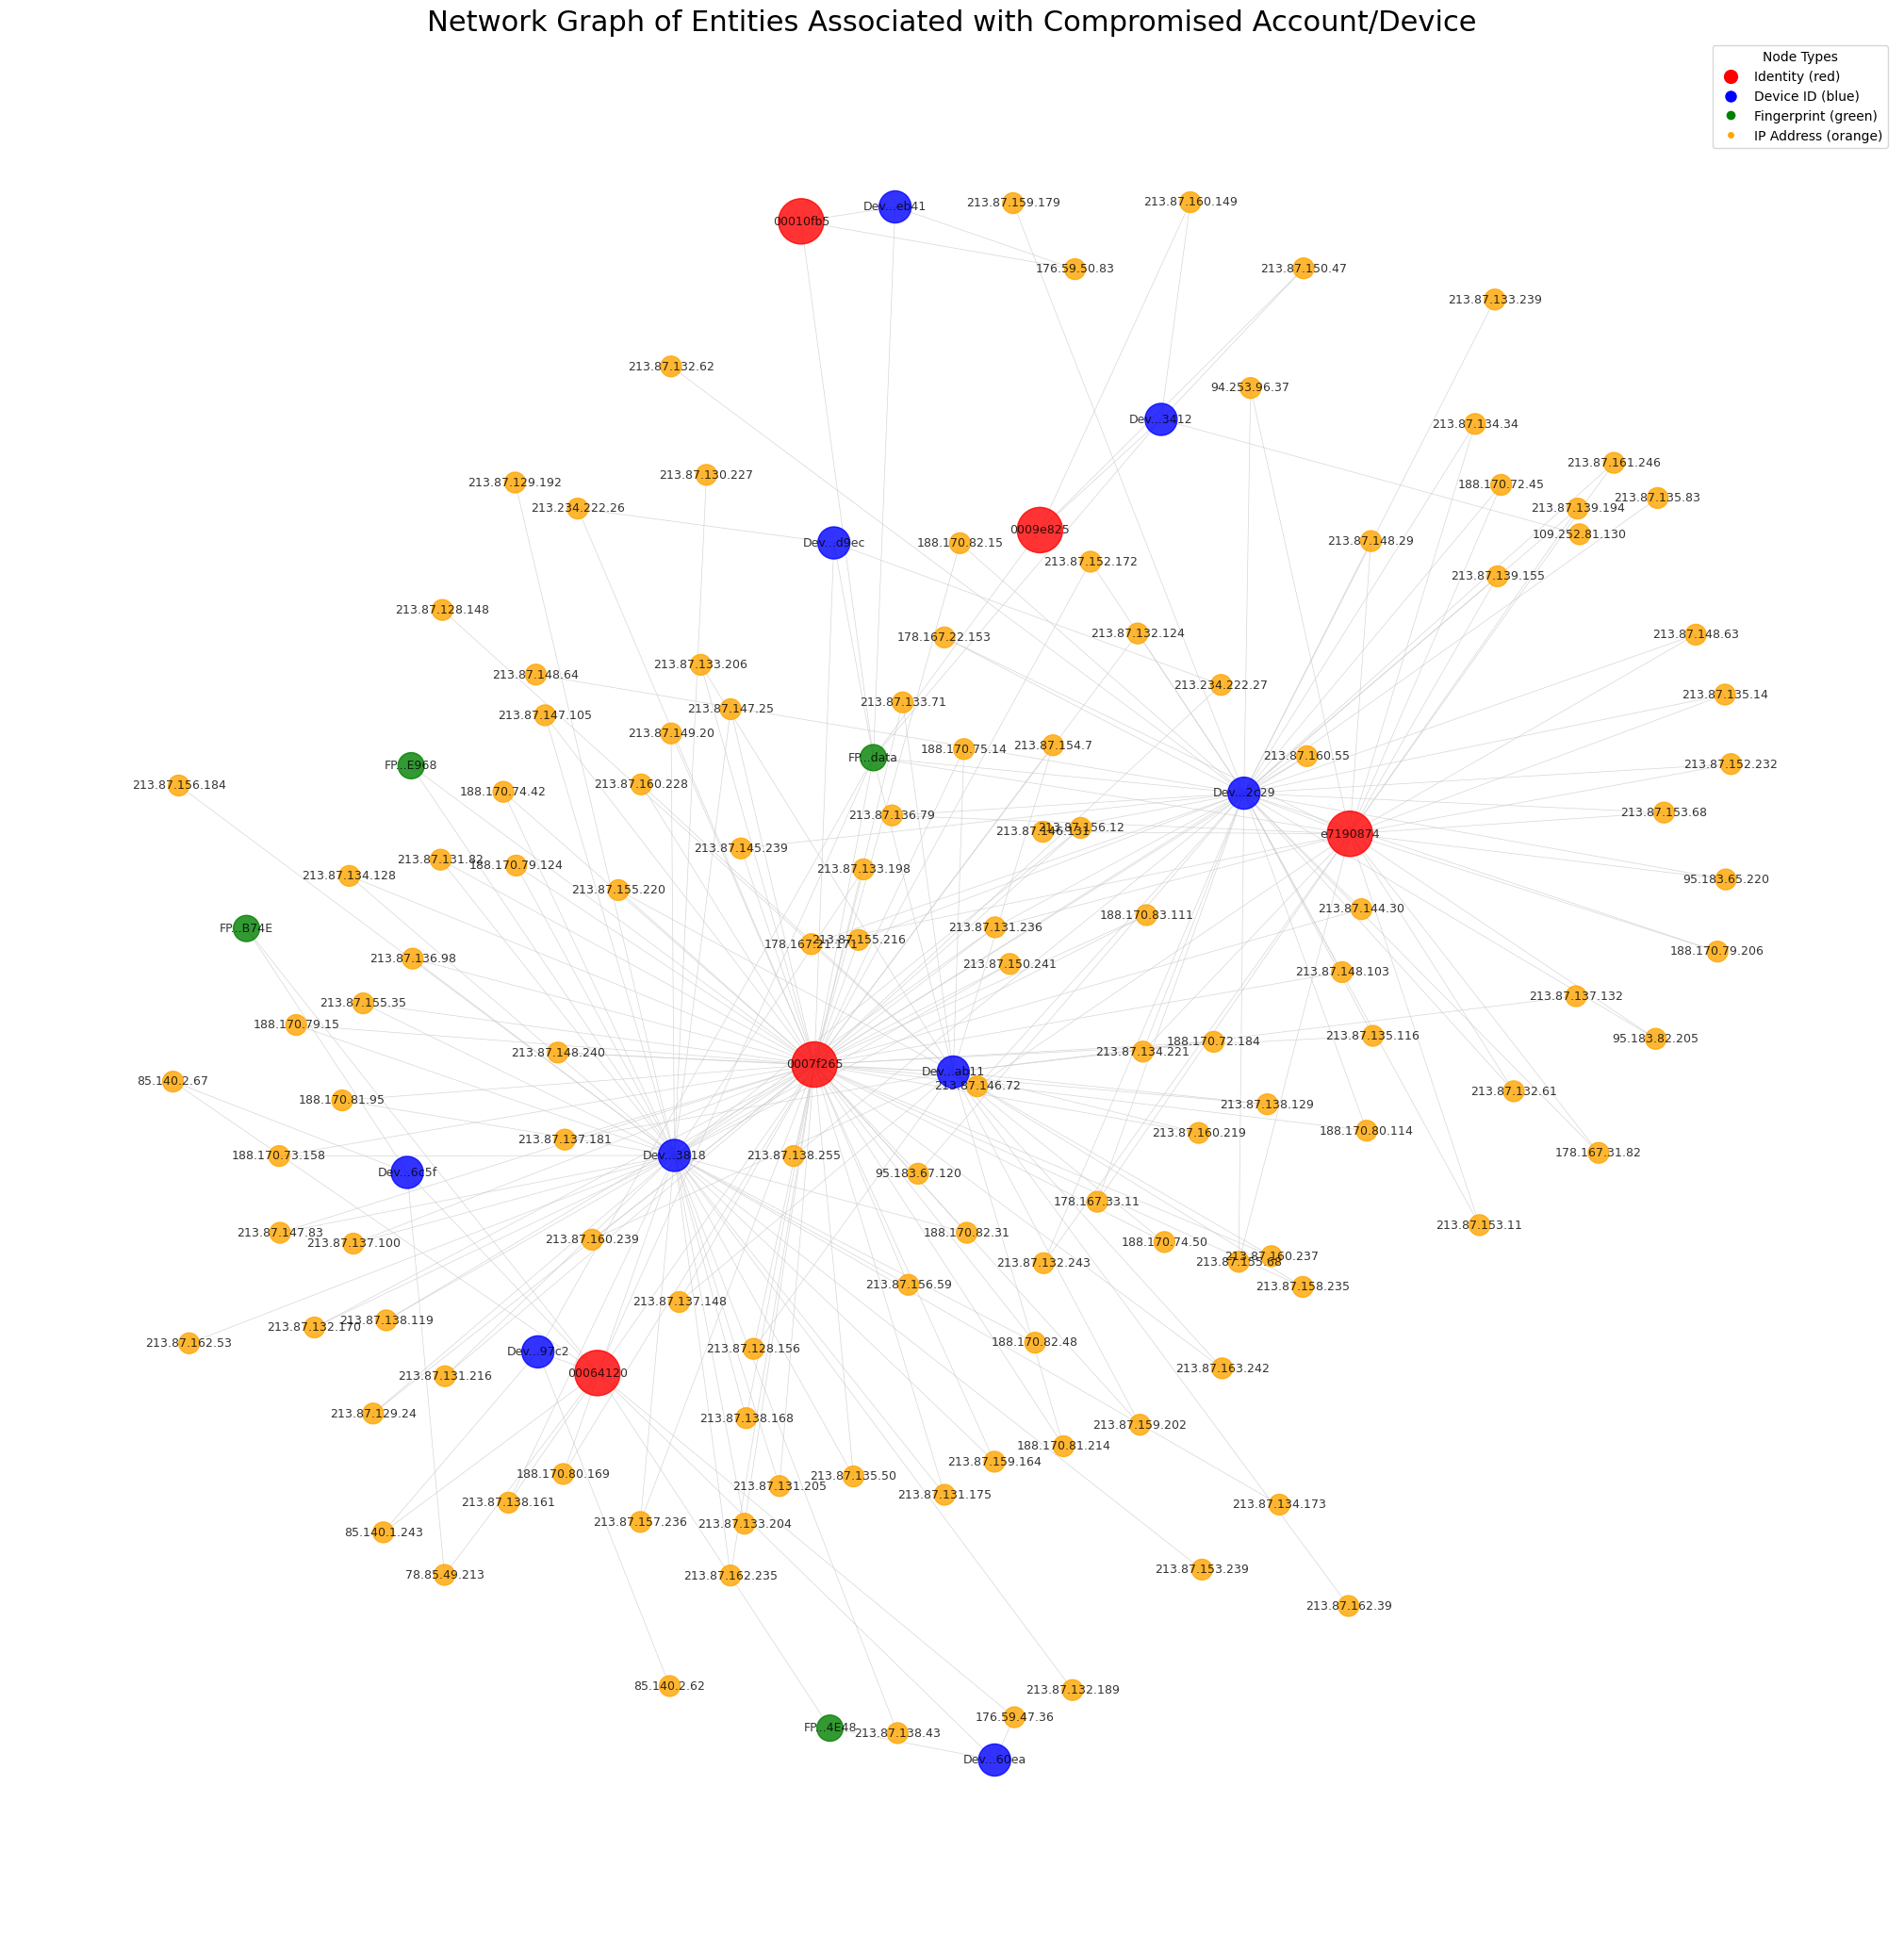

In [49]:
# For basic graph
basic_graph = create_basic_network_graph(df_associated,"graphs/basic_network.png")



#### Enhance Network Graph

Loaded 143 associated records.
Graph created with 121 nodes and 122 edges.
Network visualization saved to graphs/enhanced_network.png


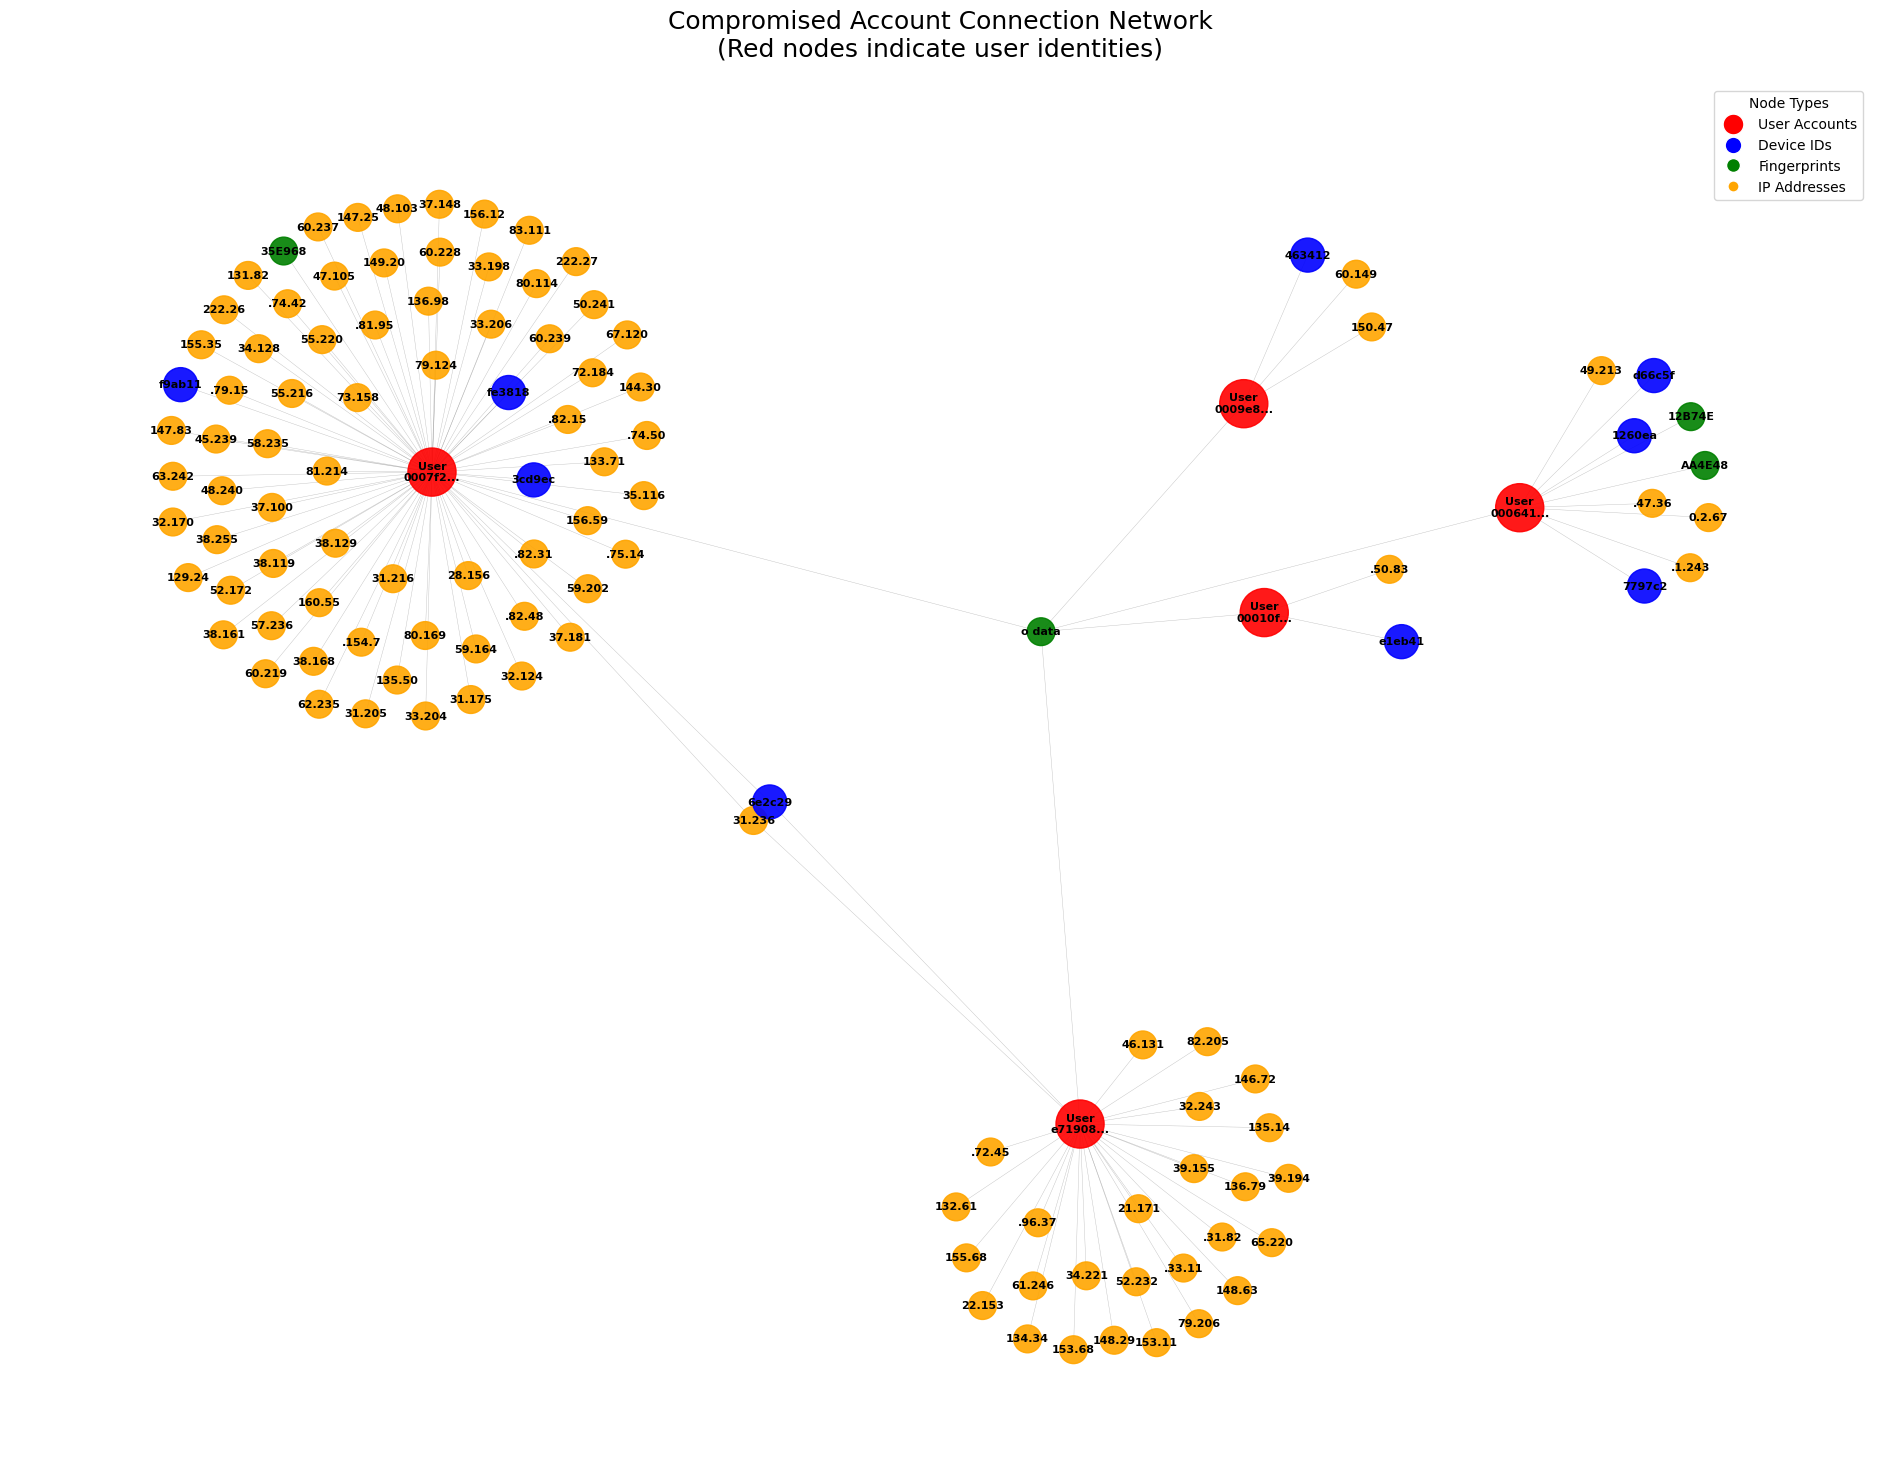

In [50]:
# For enhanced graph
enhanced_graph = create_enhanced_network_graph(df_associated, "graphs/enhanced_network.png")

#### interacted Network Graph

In [51]:
fig = create_interactive_network(df_associated,'graphs/interactive_network.html')
fig.show()  # To display in notebook

Graph created with 121 nodes and 122 edges.
Interactive network saved to graphs/interactive_network.html


## Step 5: Conclusion

This notebook performed the technical analysis requested:
1. Loaded and examined the initial data.
2. Enriched the data with IP geolocation and user agent details, saving the result to `enriched_data.csv`.
3. Identified records connected to the compromised device and user identity through shared attributes, saving results to `suspicious_connections.csv`.
4. Visualized the resulting fraud network, highlighting compromised entities and their connections, saving the image to `nasic_network.png`.

The generated files (`enriched_data.csv`, `suspicious_connections.csv`, `fraud_network.png`, and this notebook `fraud_analysis.ipynb`) serve as the artifacts for this analysis.